## Purpose
Train and evaluate multiple ML models to forecast asset returns using economic features.

Note: Early versions of the model used a globally standardized feature matrix `(StandardScaler().fit_transform(X)` across all time points). This introduces look-ahead bias, as the transformation incorporates information from future data points. All performance metrics (AUC, accuracy, precision) and plotted distributions should be interpreted with this caveat unless re-run using rolling-window scaling.

In [146]:
import os
import warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from pathlib import Path
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Define paths
PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
OPTIONAL_DATA_PATH = PROJECT_ROOT / "optional_data"
OUTPUT_PATH = PROJECT_ROOT / "data_out"

# Load the data
ff_data_path = OPTIONAL_DATA_PATH / "F-F_Research_Data_5_Factors_2x3.csv"
predictor_data_path = OPTIONAL_DATA_PATH / "PredictorData2019.csv"
returns_data_path = OPTIONAL_DATA_PATH / "returns.csv"

# Reading the data files
ff_data = pd.read_csv(ff_data_path, skiprows=3)  # Skip the first 3 rows in Fama-French data
predictor_data = pd.read_csv(predictor_data_path)
returns_data = pd.read_csv(returns_data_path)

# Convert dates to datetime format for all datasets to ensure proper merging
ff_data['Date'] = pd.to_datetime(ff_data['196308'], format='%Y%m')  # Adjusting for the specific date column format
ff_data = ff_data.drop(columns=['196308'])  # Dropping the initial column

# Convert the date columns in the predictor and returns data to datetime format
predictor_data['DATE'] = pd.to_datetime(predictor_data['DATE'], format='%m/%d/%Y')
returns_data['Date'] = pd.to_datetime(returns_data['Date'], format='%Y-%m-%d')

# Create 'YearMonth' column in all datasets to ensure proper merging
returns_data['YearMonth'] = returns_data['Date'].dt.to_period('M').astype(str)
ff_data['YearMonth'] = ff_data['Date'].dt.to_period('M').astype(str)
predictor_data['YearMonth'] = pd.to_datetime(predictor_data['DATE'], format='%m/%d/%Y').dt.to_period('M').astype(str)

# Merge all datasets on the 'YearMonth' column
merged_data = pd.merge(returns_data, ff_data, left_on='YearMonth', right_on='YearMonth', how='inner')
merged_data = pd.merge(merged_data, predictor_data, left_on='YearMonth', right_on='YearMonth', how='inner')

# Clean the merged dataset: Drop redundant date columns
merged_data = merged_data.drop(columns=['Date_x', 'Date_y'])

# Handle missing data
missing_data = merged_data.isnull().sum()

# Forward fill missing values (or you can choose to drop rows with missing values)
merged_data = merged_data.fillna(method='ffill')

# Feature Engineering: Create z-scores for the factor columns, e.g., market, SMB, HML, etc.
factor_columns = ['5.07', '-0.8', '1.8', '0.36', '-0.35', '0.25']  # Replace with actual factor columns
for col in factor_columns:
    merged_data[f'{col}_zscore'] = (merged_data[col] - merged_data[col].mean()) / merged_data[col].std()

# Final inspection of the merged and processed dataset
print(merged_data.head())

# Ensure X and y match
X = merged_data.drop(columns=['target']).values  # Exclude 'target' column
y = merged_data['target'].shift(-1).dropna().values  # Shifting to get the next day's returns as target

# Double-check shapes
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print(merged_data.columns.tolist())

# Save the final merged dataset to a CSV file
merged_data.to_csv(OUTPUT_PATH / "merged_data.csv" , index=False)

   target YearMonth  5.07  -0.8   1.8  0.36  -0.35  0.25       DATE  Index  \
0 -0.0157   1963-09 -1.57 -0.52  0.13 -0.71   0.29  0.27 1963-09-30  71.70   
1  0.0253   1963-10  2.53 -1.39 -0.10  2.80  -2.01  0.29 1963-10-31  74.01   
2 -0.0085   1963-11 -0.85 -0.88  1.75 -0.51   2.24  0.27 1963-11-30  73.23   
3  0.0183   1963-12  1.83 -2.10 -0.02  0.03  -0.07  0.29 1963-12-31  75.02   
4  0.0224   1964-01  2.24  0.13  1.48  0.17   1.47  0.30 1964-01-31  77.04   

   ...      svar       csp  CRSP_SPvw  CRSP_SPvwx  5.07_zscore  -0.8_zscore  \
0  ...  0.000330 -0.001524  -0.010402   -0.011579    -0.479810    -0.249264   
1  ...  0.000504 -0.001756   0.034825    0.033290     0.454343    -0.538165   
2  ...  0.003110 -0.001758  -0.004487   -0.011085    -0.315764    -0.368809   
3  ...  0.000274 -0.001497   0.026065    0.024651     0.294853    -0.773935   
4  ...  0.000183 -0.001728   0.027391    0.026373     0.388269    -0.033418   

   1.8_zscore  0.36_zscore  -0.35_zscore  0.25_zscore  


/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_84654/3122144199.py:52: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data = merged_data.fillna(method='ffill')


['5.07', '-0.8', '1.8', '0.36', '-0.35', '0.25', 'Index', 'D12', 'E12', 'b/m', 'tbl', 'AAA', 'BAA', 'lty', 'ntis', 'Rfree', 'infl', 'ltr', 'corpr', 'svar', 'csp', 'CRSP_SPvw', 'CRSP_SPvwx', '5.07_zscore', '-0.8_zscore', '1.8_zscore', '0.36_zscore', '-0.35_zscore', '0.25_zscore']
(675, 29) (675,)
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=200; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=200; to

Text(0.5, 1.0, 'XGBoost Residuals Over Time')

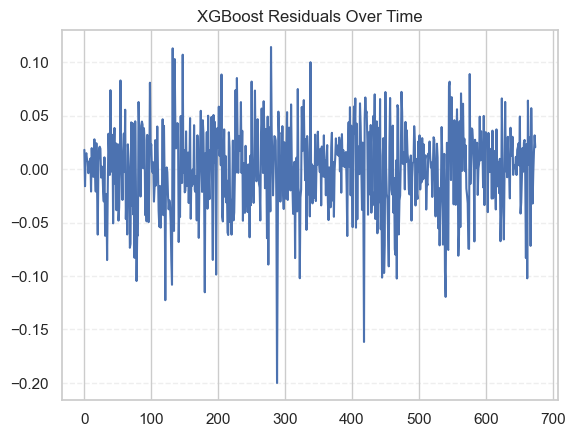

In [147]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

# Drop non-numeric columns and extract X matrix
X_cleaned = (
    merged_data
    .select_dtypes(include=[np.number])  # keep only numeric columns
    .drop(columns=['target'])            # remove the target variable
    .iloc[:-1]                           # align with shifted y
    .values
)

# Define target y: future 1-period-ahead return
y_cleaned = (
    merged_data['target']
    .shift(-1)      # predict next period’s return
    .dropna()
    .values
)

# Rebuild X_cleaned as a DataFrame with column names
X_cols = merged_data.select_dtypes(include=[np.number]).drop(columns=["target"]).columns
X_cleaned_df = pd.DataFrame(X_cleaned, columns=X_cols)

# Align y
y_cleaned_df = pd.Series(y_cleaned, name="target")

# Display cleaned data shapes and columns
print(X_cleaned_df.columns.tolist())
print(X_cleaned_df.shape, y_cleaned_df.shape)

# Save for external use (significance testing)
X_cleaned_df.to_csv(OUTPUT_PATH / "X_cleaned.csv")
y_cleaned_df.to_csv(OUTPUT_PATH / "y_cleaned.csv")

# TimeSeriesSplit for temporal validation
tscv = TimeSeriesSplit(n_splits=5)

# XGBoost with time-series CV
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(random_state=42))
])

xgb_param_grid = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.3],
    'xgb__n_estimators': [100, 200, 500]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

xgb_grid_search.fit(X_cleaned, y_cleaned)
print("Best parameters for XGBoost:", xgb_grid_search.best_params_)

# MLP with time-series CV
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=10000, random_state=42))
])

mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (150,)],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01, 0.1]
}

mlp_grid_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

mlp_grid_search.fit(X_cleaned, y_cleaned)
print("Best parameters for MLP:", mlp_grid_search.best_params_)

# Evaluate best estimators
xgb_cv_score = cross_val_score(
    xgb_grid_search.best_estimator_, X_cleaned, y_cleaned, cv=tscv, scoring='r2'
)
print("XGBoost Cross-validation R² scores:", xgb_cv_score)
print("Average XGBoost R² score:", xgb_cv_score.mean())

mlp_cv_score = cross_val_score(
    mlp_grid_search.best_estimator_, X_cleaned, y_cleaned, cv=tscv, scoring='r2'
)
print("MLP Cross-validation R² scores:", mlp_cv_score)
print("Average MLP R² score:", mlp_cv_score.mean())

y_pred = xgb_grid_search.best_estimator_.predict(X_cleaned)
residuals = y_cleaned - y_pred
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.plot(residuals)

plt.title("XGBoost Residuals Over Time")

### Hybrid Model

In [148]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFECV
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# Prepare data
X_df = pd.DataFrame(X_cleaned, columns=[f"x{i}" for i in range(X_cleaned.shape[1])])
y_series = pd.Series(y_cleaned, index=X_df.index)

def create_lagged_features(X, y, lags=3):
    X_lagged = pd.DataFrame(index=X.index)
    for lag in range(1, lags + 1):
        X_lagged = pd.concat([X_lagged, X.shift(lag).add_suffix(f"_lag{lag}")], axis=1)
    valid_idx = X_lagged.dropna().index
    return X_lagged.loc[valid_idx], y.loc[valid_idx]

X_lagged, y_lagged = create_lagged_features(X_df, y_series, lags=3)

# Feature Selection
tscv = TimeSeriesSplit(n_splits=5)
xgb_for_selection = XGBRegressor(random_state=42)
selector = RFECV(estimator=xgb_for_selection, cv=tscv, scoring='r2', n_jobs=-1)
selector.fit(X_lagged, y_lagged)

X_selected = X_lagged.loc[:, selector.support_]
print(f"Selected {X_selected.shape[1]} features out of {X_lagged.shape[1]}")

# XGBoost on selected features
xgb_final = XGBRegressor(**grid_search.best_params_, random_state=42)
xgb_final.fit(X_selected, y_lagged)
y_pred_xgb = xgb_final.predict(X_selected)

# MLP on residuals
residuals = y_lagged - y_pred_xgb
mlp_params = {k.split("__")[-1]: v for k, v in mlp_grid_search.best_params_.items()}
mlp = MLPRegressor(**mlp_params, max_iter=1000, random_state=42)
mlp.fit(X_selected, residuals)

# Final Hybrid Prediction
residual_pred = mlp.predict(X_selected)
y_pred_hybrid = y_pred_xgb + residual_pred
r2_hybrid = r2_score(y_lagged, y_pred_hybrid)

print("R² (Hybrid Model):", round(r2_hybrid, 4))

Selected 25 features out of 87


/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "hidden_layer_sizes", "learning_rate_init" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


R² (Hybrid Model): -5.2195


### XGB Model

In [149]:
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# Prep: Turn arrays into named structures
X_df = pd.DataFrame(X_cleaned, columns=[f"x{i}" for i in range(X_cleaned.shape[1])])
y_series = pd.Series(y_cleaned, index=X_df.index)

def create_lagged_features(X, y, lags=3):
    X_lagged = pd.DataFrame(index=X.index)
    for lag in range(1, lags + 1):
        lagged = X.shift(lag).add_suffix(f"_lag{lag}")
        X_lagged = pd.concat([X_lagged, lagged], axis=1)
    y_lagged = y.copy()
    valid_idx = X_lagged.dropna().index
    return X_lagged.loc[valid_idx], y_lagged.loc[valid_idx]

# Create lagged features
X_lagged, y_lagged = create_lagged_features(X_df, y_series, lags=3)

# Time-series aware CV
tscv = TimeSeriesSplit(n_splits=5)

# Use existing best parameters from earlier grid search
xgb = XGBRegressor(**grid_search.best_params_, random_state=42)

# Feature selection via recursive elimination
selector = RFECV(estimator=xgb, cv=tscv, scoring='r2', n_jobs=-1)
selector.fit(X_lagged, y_lagged)

# Select top features
X_selected = X_lagged.loc[:, selector.support_]
print(f"Selected {X_selected.shape[1]} features out of {X_lagged.shape[1]}")

# Fit XGBoost using selected features
xgb.fit(X_selected, y_lagged)
y_pred_xgb = xgb.predict(X_selected)

# Evaluate
r2 = r2_score(y_lagged, y_pred_xgb)
print("R² (XGBoost):", round(r2, 4))

/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "hidden_layer_sizes", "learning_rate_init" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "hidden_layer_sizes", "learning_rate_init" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "hidden_layer_sizes", "lear

Selected 12 features out of 87
R² (XGBoost): 0.9978


/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [14:22:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "hidden_layer_sizes", "learning_rate_init" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [150]:
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

def rolling_xgb_forecast(X, y, window=60):
    preds, actuals = [], []

    for i in range(window, len(X)):
        # Training data
        X_train = X.iloc[i-window:i]
        y_train = y.iloc[i-window:i]

        # Test point
        X_test = X.iloc[i:i+1]

        # Scale using training data only
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Fit model
        model = XGBRegressor(random_state=42)
        model.fit(X_train_scaled, y_train)

        # Predict
        pred = model.predict(X_test_scaled)[0]
        preds.append(pred)
        actuals.append(y.iloc[i])

    return np.array(preds), np.array(actuals)

y_pred_roll, y_true_roll = rolling_xgb_forecast(X_lagged, y_lagged, window=60)

### Cumulative Return

R²: -0.543
Accuracy (directional): 0.557
Precision (when predicting up): 0.615
AUC (ranking skill): 0.529
Estimated Sharpe Ratio: 0.167


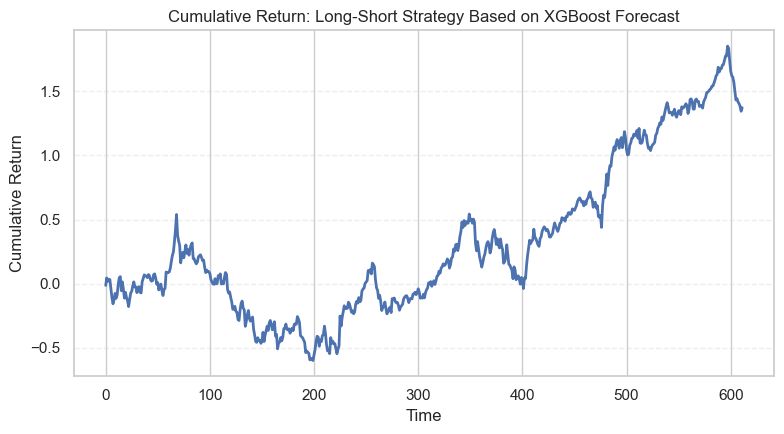

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, accuracy_score, precision_score, roc_auc_score

FIGURES = PROJECT_ROOT / "figures"

# R² Score
r2 = r2_score(y_true_roll, y_pred_roll)

# Binary predictions and ground truth
y_true_binary = (y_true_roll > 0).astype(int)
y_pred_binary = (y_pred_roll > 0).astype(int)

# Classification metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary)
auc = roc_auc_score(y_true_binary, y_pred_roll)

# Sharpe ratio (assume no risk-free rate, daily returns)
excess_returns = y_true_binary * y_pred_roll  # only count positive predictions
sharpe = np.mean(excess_returns) / np.std(excess_returns)

# Print results
print(f"R²: {r2:.3f}")
print(f"Accuracy (directional): {accuracy:.3f}")
print(f"Precision (when predicting up): {precision:.3f}")
print(f"AUC (ranking skill): {auc:.3f}")
print(f"Estimated Sharpe Ratio: {sharpe:.3f}")

# Long-short strategy: sign(pred) * true_return
long_short_return = np.sign(y_pred_roll) * y_true_roll
cumulative_return = np.cumsum(long_short_return)

plt.figure(figsize=(8, 4.5))
plt.plot(cumulative_return, linewidth=2)
plt.title("Cumulative Return: Long-Short Strategy Based on XGBoost Forecast")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "xgboost_cumulative_return.png", dpi=300)
plt.show()

### Lasso, Ridge, RandomForest, XGboost, MLP

In [152]:
# Rolling forecast function (fixed)
# def rolling_forecast(model, X, y, window=60):
#     preds, actuals = [], []
#     for i in range(window, len(X)):
#         model.fit(X[i-window:i], y[i-window:i])
#         preds.append(model.predict(X[i].reshape(1, -1))[0])
#         actuals.append(y[i])
#     return np.array(preds), np.array(actuals)

def rolling_forecast(model, X, y, window=60):
    preds, actuals = [], []
    for i in range(window, len(X)):
        # Ensure that non-numeric columns like Date/YearMonth are excluded from X
        X_train = X[i-window:i, :]
        y_train = y[i-window:i]
        model.fit(X_train, y_train)
        preds.append(model.predict(X[i].reshape(1, -1))[0])
        actuals.append(y[i])
    return np.array(preds), np.array(actuals)

# Define models to evaluate
models = {
    "Lasso": Lasso(alpha=0.01, max_iter=10000, random_state=42),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "MLP": MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
}

# Select only numeric columns, ensuring that no datetime columns are included in X_cleaned
numeric_columns = merged_data.select_dtypes(include=[np.number]).columns.tolist()

# Ensure non-numeric columns like 'Date' and 'YearMonth' are excluded from X
X_cleaned = (
    merged_data
    .select_dtypes(include=[np.number])  # only keep numeric columns
    .drop(columns=['target'])            # remove target
    .copy()
)

# Also drop final row from X to match y_cleaned's length
X_cleaned = X_cleaned.iloc[:-1].values
y_cleaned = merged_data['target'].shift(-1).dropna().values  # Shifting target by one to predict the next time period's returns

# Double-check shapes
print("Final X shape:", X_cleaned.shape)
print("Final y shape:", y_cleaned.shape)

# Inspect a sample row to find the offending Timestamp
for i, col in enumerate(merged_data.columns):
    val = merged_data[col].iloc[0]
    print(f"{col}: {val} ({type(val)})")


# Evaluation loop (with NaN/constant check)
# results = {}
# for name, model in models.items():
#     print(f"Evaluating {name}...")
#     pred, actual = rolling_forecast(model, X, y)
#     if np.std(pred) == 0 or np.std(actual) == 0:
#         r2, ic = np.nan, np.nan
#     else:
#         r2 = r2_score(actual, pred)
#         ic = np.corrcoef(actual, pred)[0, 1]
#     results[name] = {"R^2": r2, "IC": ic}

results = {}
for name, model in models.items():
    print(f"Evaluating {name}...")
    pred, actual = rolling_forecast(model, X_cleaned, y_cleaned)
    if np.std(pred) == 0 or np.std(actual) == 0:
        r2, ic = np.nan, np.nan
    else:
        r2 = r2_score(actual, pred)
        ic = np.corrcoef(actual, pred)[0, 1]
    results[name] = {"R^2": r2, "IC": ic}

# Display results
results_df = pd.DataFrame(results).T
display(results_df)
pd.DataFrame(results).T

Final X shape: (675, 29)
Final y shape: (675,)
target: -0.0157 (<class 'numpy.float64'>)
YearMonth: 1963-09 (<class 'str'>)
5.07: -1.57 (<class 'numpy.float64'>)
-0.8: -0.52 (<class 'numpy.float64'>)
1.8: 0.13 (<class 'numpy.float64'>)
0.36: -0.71 (<class 'numpy.float64'>)
-0.35: 0.29 (<class 'numpy.float64'>)
0.25: 0.27 (<class 'numpy.float64'>)
DATE: 1963-09-30 00:00:00 (<class 'pandas._libs.tslibs.timestamps.Timestamp'>)
Index: 71.7 (<class 'numpy.float64'>)
D12: 2.21 (<class 'numpy.float64'>)
E12: 3.96 (<class 'numpy.float64'>)
b/m: 0.547223625 (<class 'numpy.float64'>)
tbl: 0.0338 (<class 'numpy.float64'>)
AAA: 0.0431 (<class 'numpy.float64'>)
BAA: 0.0484 (<class 'numpy.float64'>)
lty: 0.041 (<class 'numpy.float64'>)
ntis: 0.010313262 (<class 'numpy.float64'>)
Rfree: 0.002816667 (<class 'numpy.float64'>)
infl: 0.0 (<class 'numpy.float64'>)
ltr: 0.0004 (<class 'numpy.float64'>)
corpr: -0.0023 (<class 'numpy.float64'>)
svar: 0.000329888 (<class 'numpy.float64'>)
csp: -0.001524392 (<

,R^2,IC
Lasso,-0.086989,0.016343
Ridge,-0.245008,0.019085
RandomForest,-0.142054,0.106072
XGBoost,-0.523400,0.105530
MLP,-29878.077813,0.058339


,R^2,IC
Lasso,-0.086989,0.016343
Ridge,-0.245008,0.019085
RandomForest,-0.142054,0.106072
XGBoost,-0.523400,0.105530
MLP,-29878.077813,0.058339


### MLP Model

In [153]:
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Scale the feature set X_cleaned
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)

# Define hyperparameter grid for XGBoost
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 500]
}

# Initialize the model and GridSearchCV
xgb_model = XGBRegressor(random_state=42)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to find best parameters
grid_search.fit(X_scaled, y_cleaned)

# Best hyperparameters for XGBoost
print("Best parameters for XGBoost:", grid_search.best_params_)

# Define hyperparameter grid for MLP
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# Initialize MLP model and GridSearchCV
mlp_model = MLPRegressor(max_iter=1000, random_state=42)
mlp_grid_search = GridSearchCV(estimator=mlp_model, param_grid=mlp_param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to find best parameters
mlp_grid_search.fit(X_scaled, y_cleaned)

# Best hyperparameters for MLP
print("Best parameters for MLP:", mlp_grid_search.best_params_)

# Cross-validation for XGBoost
xgb_best_model = XGBRegressor(**grid_search.best_params_, random_state=42)
xgb_cv_score = cross_val_score(xgb_best_model, X_scaled, y_cleaned, cv=5, scoring='r2')
print("XGBoost Cross-validation R² scores:", xgb_cv_score)
print("Average XGBoost R² score:", xgb_cv_score.mean())

# Cross-validation for MLP
mlp_best_model = MLPRegressor(**mlp_grid_search.best_params_, max_iter=1000, random_state=42)
mlp_cv_score = cross_val_score(mlp_best_model, X_scaled, y_cleaned, cv=5, scoring='r2')
print("MLP Cross-validation R² scores:", mlp_cv_score)
print("Average MLP R² score:", mlp_cv_score.mean())

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_e

/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ...learning_rate=0.3, max_depth=3, n_estimators=500; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=200; total time=   0.4s
[CV] END ...learning_rate=0.3, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.3, max_depth=5, n_estimators=100; total time=   0.2s
[CV] END ...learning_rate=0.3, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=200; total time=   0.5s
[CV] END ...learning_rate=0.3, max_depth=3, n_estimators=500; total time=   0.2s
[CV] END ...learning_rate=0.3, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.3, max_depth=3, n_estimators=500; total time=   0.2s
[CV] END ...learning_rate=0.3, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ...learning_rate=0.3, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=500; total time=   0.5s
[CV] END ...learning_rate=0.

### Model Evaluation

Evaluating Lasso...
Evaluating Ridge...
Evaluating RandomForest...
Evaluating XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_dept

/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_84654/3521398522.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['R^2'], palette="viridis")


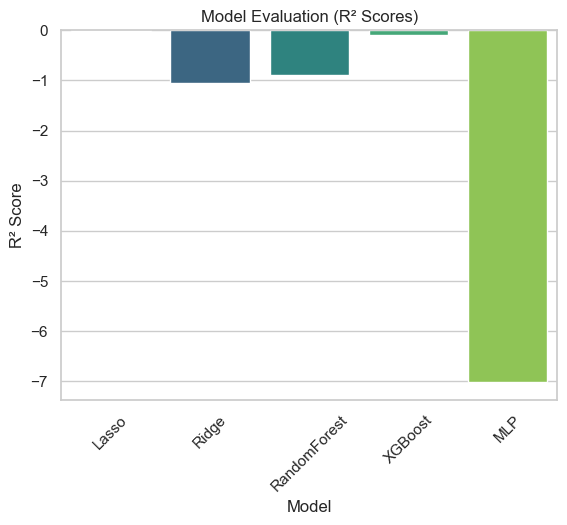

In [154]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Feature scaling with StandardScaler (for models like Lasso, Ridge)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)  # Scaling the features

# Cross-validation strategy (TimeSeriesSplit for time series data)
tscv = TimeSeriesSplit(n_splits=5)  # 5-fold time series split

# Hyperparameter grid for GridSearchCV
xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 500]
}

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# Evaluation loop (with NaN/constant check)
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Hyperparameter tuning for specific models (XGBoost and MLP)
    if name == "XGBoost":
        grid_search = GridSearchCV(model, xgb_param_grid, cv=tscv, n_jobs=-1, verbose=2)
        grid_search.fit(X_scaled, y_cleaned)
        best_model = grid_search.best_estimator_
        print("Best parameters for XGBoost:", grid_search.best_params_)
    elif name == "MLP":
        grid_search = GridSearchCV(model, mlp_param_grid, cv=tscv, n_jobs=-1, verbose=2)
        grid_search.fit(X_scaled, y_cleaned)
        best_model = grid_search.best_estimator_
        print("Best parameters for MLP:", grid_search.best_params_)
    else:
        best_model = model
    
    # Cross-validation for model evaluation
    cv_score = cross_val_score(best_model, X_scaled, y_cleaned, cv=tscv, scoring='r2')
    
    # Store results for each model
    results[name] = {
        "R^2": cv_score.mean(),
        "Standard Deviation": cv_score.std()
    }

# Display the results
results_df = pd.DataFrame(results).T
print(results_df)

# Final clean up and display
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the results
sns.barplot(x=results_df.index, y=results_df['R^2'], palette="viridis")
plt.title("Model Evaluation (R² Scores)")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.show()

MLP Cross-validation R² scores: [-2.68370831 -2.23768419 -0.25851079 -1.68790481 -3.96399952]
Average MLP R² score: -2.166361526257446


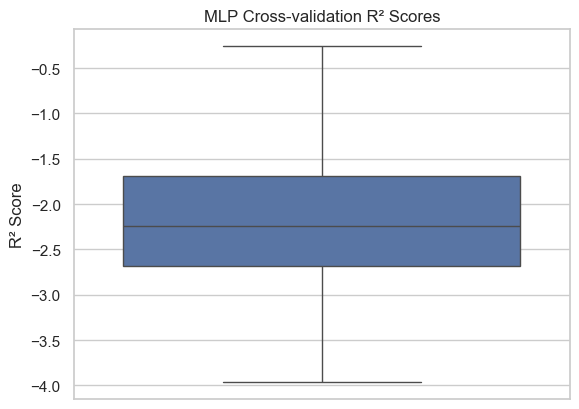

In [155]:
from sklearn.model_selection import cross_val_score

# Evaluate MLP with Cross-Validation
mlp_best_model = MLPRegressor(**mlp_grid_search.best_params_, max_iter=1000, random_state=42)
mlp_cv_score = cross_val_score(mlp_best_model, X_scaled, y_cleaned, cv=5, scoring='r2')

# Print the cross-validation scores for MLP
print("MLP Cross-validation R² scores:", mlp_cv_score)
print("Average MLP R² score:", mlp_cv_score.mean())

# Plotting Cross-validation results for MLP
sns.boxplot(y=mlp_cv_score)
plt.title("MLP Cross-validation R² Scores")
plt.ylabel("R² Score")
plt.show()

### Feature Engineering & Hyperparameter Tuning for MLP

In [156]:
# Expanded hyperparameter grid for XGBoost
xgb_param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500, 1000],
    'subsample': [0.8, 0.9, 1.0],  # Adding subsample for regularization
    'colsample_bytree': [0.7, 0.8, 0.9]  # Adding colsample_bytree for feature selection
}

# Grid Search for XGBoost
xgb_grid_search = GridSearchCV(estimator=XGBRegressor(random_state=42), param_grid=xgb_param_grid, cv=5, n_jobs=-1, verbose=2)
xgb_grid_search.fit(X_scaled, y_cleaned)

# Best parameters for XGBoost
print("Best parameters for XGBoost:", xgb_grid_search.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   0.0s
[CV] END

/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/final-venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, n_estimators=200, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=1000, subsample=0.9; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, n_estimators=200, subsample=1.0; total time=   1.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=1000, subsample=1.0; total time=   2.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.8; total time=   2.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.9; total time=   1.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, n_estimators=500, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_esti

In [157]:
# Expanded hyperparameter grid for MLP
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (200,)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [1000, 2000, 5000]  # Exploring more iterations for convergence
}

# Grid Search for MLP
mlp_grid_search = GridSearchCV(estimator=MLPRegressor(random_state=42), param_grid=mlp_param_grid, cv=5, n_jobs=-1, verbose=2)
mlp_grid_search.fit(X_scaled, y_cleaned)

# Best parameters for MLP
print("Best parameters for MLP:", mlp_grid_search.best_params_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=1000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=1000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=1000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=1000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=1000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=2000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=2000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_init=0.001, max_iter=2000; total time=   0.0s
[CV] END alpha=0.0001, hidden_layer_sizes=(50,), learning_rate_in

In [158]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features (degree 2 for simplicity)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# Train models on the polynomial features
xgb_poly = XGBRegressor(n_estimators=100, random_state=42)
xgb_poly.fit(X_poly, y_cleaned)

# Evaluate performance with cross-validation on the polynomial features
xgb_poly_cv_score = cross_val_score(xgb_poly, X_poly, y_cleaned, cv=5, scoring='r2')
print("XGBoost with Polynomial Features R² scores:", xgb_poly_cv_score)
print("Average XGBoost with Polynomial Features R² score:", xgb_poly_cv_score.mean())

XGBoost with Polynomial Features R² scores: [-0.55730461 -0.12820568 -0.09644345 -0.32125961 -0.44498268]
Average XGBoost with Polynomial Features R² score: -0.3096392070313872


In [159]:
from sklearn.preprocessing import PolynomialFeatures

# Generate interaction features (degree 2 for interactions)
interaction = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interaction = interaction.fit_transform(X_scaled)

# Train models on the interaction features
xgb_interaction = XGBRegressor(n_estimators=100, random_state=42)
xgb_interaction.fit(X_interaction, y_cleaned)

# Evaluate performance with cross-validation on interaction features
xgb_interaction_cv_score = cross_val_score(xgb_interaction, X_interaction, y_cleaned, cv=5, scoring='r2')
print("XGBoost with Interaction Features R² scores:", xgb_interaction_cv_score)
print("Average XGBoost with Interaction Features R² score:", xgb_interaction_cv_score.mean())

XGBoost with Interaction Features R² scores: [-0.62809047 -0.03092493 -0.11840391 -0.2415232  -0.45297756]
Average XGBoost with Interaction Features R² score: -0.29438401078023746


/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_84654/3460703619.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_scores, palette="Blues_d")


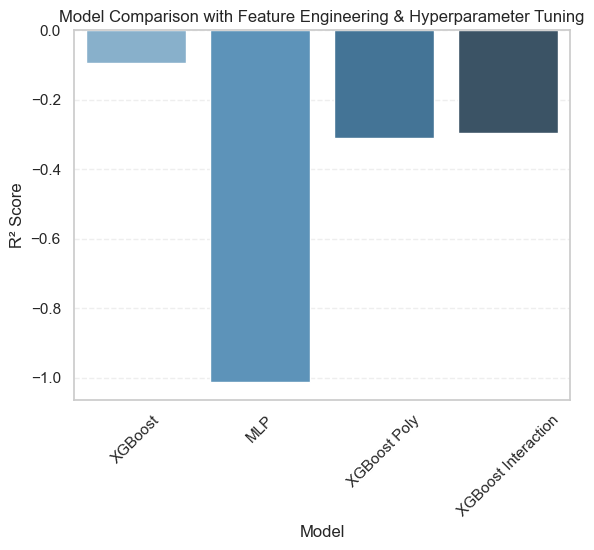

In [160]:
# Plot the R² scores of models after tuning and feature engineering
model_names = ['XGBoost', 'MLP', 'XGBoost Poly', 'XGBoost Interaction']
r2_scores = [
    xgb_grid_search.best_score_,  # XGBoost R²
    mlp_grid_search.best_score_,  # MLP R²
    xgb_poly_cv_score.mean(),    # XGBoost with Polynomial Features R²
    xgb_interaction_cv_score.mean()  # XGBoost with Interaction Features R²
]

# Bar plot to compare models
sns.barplot(x=model_names, y=r2_scores, palette="Blues_d")
plt.title("Model Comparison with Feature Engineering & Hyperparameter Tuning")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.show()

In [161]:
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit

# Apply early stopping with a convergence tolerance (MLP)
mlp_model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=42, tol=1e-4, early_stopping=True, n_iter_no_change=10)

# Fit the model
mlp_model.fit(X_scaled, y_cleaned)

# Apply L1 and L2 regularization for XGBoost
model = XGBRegressor(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=500,
    alpha=0.1,       # L1 regularization
    reg_lambda=0.5,  # correct param name in sklearn API
    random_state=42
)

# Fit the model
xgb_model.fit(X_scaled, y_cleaned)

# Cross-validation using TimeSeriesSplit for time series data
tscv = TimeSeriesSplit(n_splits=5)

# Evaluate model performance using TimeSeriesSplit cross-validation
cv_score = cross_val_score(mlp_model, X_scaled, y_cleaned, cv=tscv, scoring='r2')
print("Cross-validation R² scores:", cv_score)
print("Average R² score:", cv_score.mean())

Cross-validation R² scores: [ -90.36245855  -36.95549992 -266.47305448  -80.74621515  -26.57640169]
Average R² score: -100.22272595861263


R² of mean prediction (baseline): 0.0


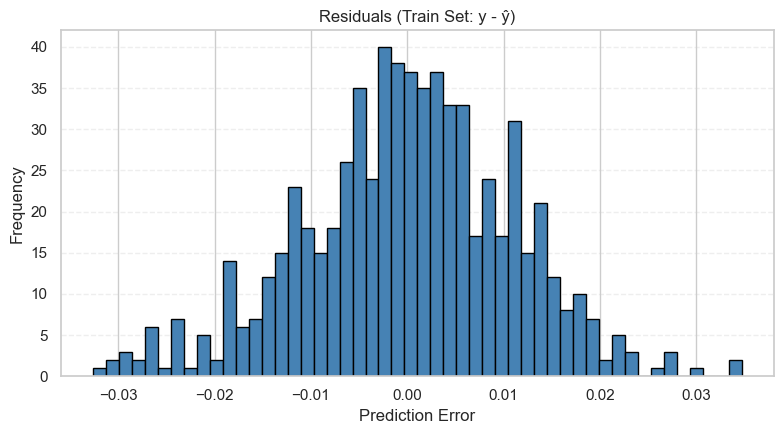

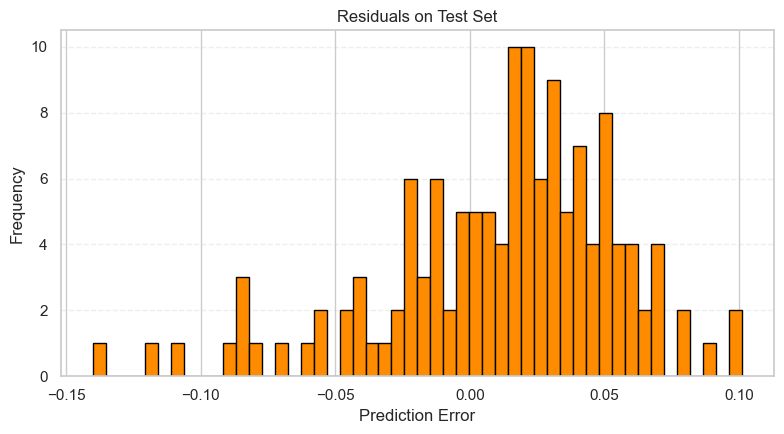

In [162]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pathlib import Path

PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Baseline R² from predicting the mean
y_mean = np.full_like(y_cleaned, np.mean(y_cleaned))
r2_baseline = r2_score(y_cleaned, y_mean)
print("R² of mean prediction (baseline):", r2_baseline)

# Optional log-transform fpr skew/negative values
# epsilon = 1e-4
# y_transformed = np.log1p(y_cleaned + epsilon)

# Standardize target if needed
target_scaler = StandardScaler()
y_cleaned_std = target_scaler.fit_transform(y_cleaned.reshape(-1, 1)).ravel()

# Fit model on full data
model.fit(X_scaled, y_cleaned)
y_pred = model.predict(X_scaled)
residuals = y_cleaned - y_pred

# Plot & save residuals on full data
plt.figure(figsize=(8, 4.5))
plt.hist(residuals, bins=50, color="steelblue", edgecolor="black")
plt.title("Residuals (Train Set: y - ŷ)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "train_residuals.png", dpi=300)
plt.show()

# Train/test split and re-evaluation
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cleaned, test_size=0.2, shuffle=False)
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
residuals_test = y_test - y_pred_test

# Plot and save residuals on test set
plt.figure(figsize=(8, 4.5))
plt.hist(residuals_test, bins=50, color="darkorange", edgecolor="black")
plt.title("Residuals on Test Set")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "test_residuals.png", dpi=300)
plt.show()

In [163]:
from sklearn.ensemble import BaggingRegressor
from xgboost import XGBRegressor

# Define the base XGBoost model with your tuned parameters
xgb_base = XGBRegressor(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=500,
    alpha=0.1,
    reg_lambda=0.5,
    random_state=42
)

# Bag the model correctly using the new API
bagged_model = BaggingRegressor(
    estimator=xgb_base,   # ✅ corrected keyword
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

# Fit and predict
bagged_model.fit(X_train, y_train)
y_pred_bagged = bagged_model.predict(X_test)
residuals_bagged = y_test - y_pred_bagged

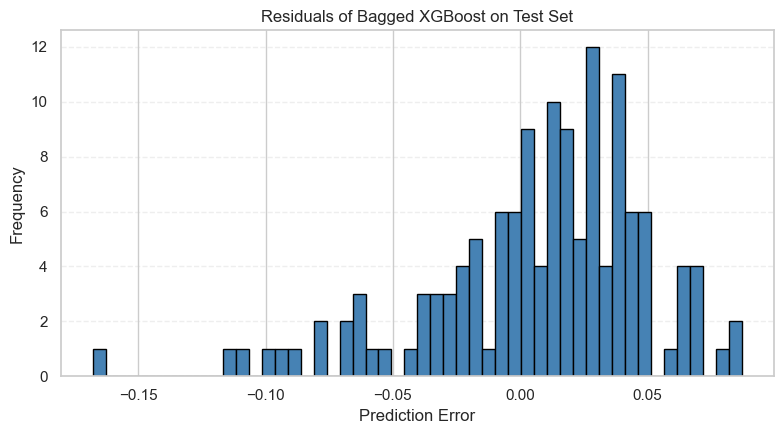

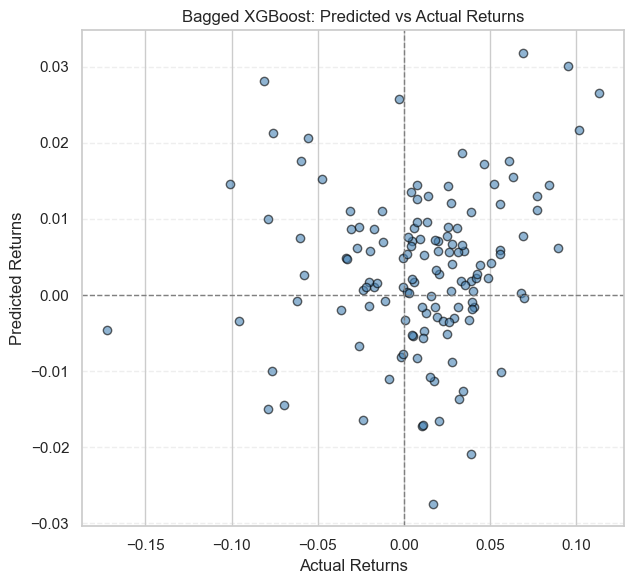

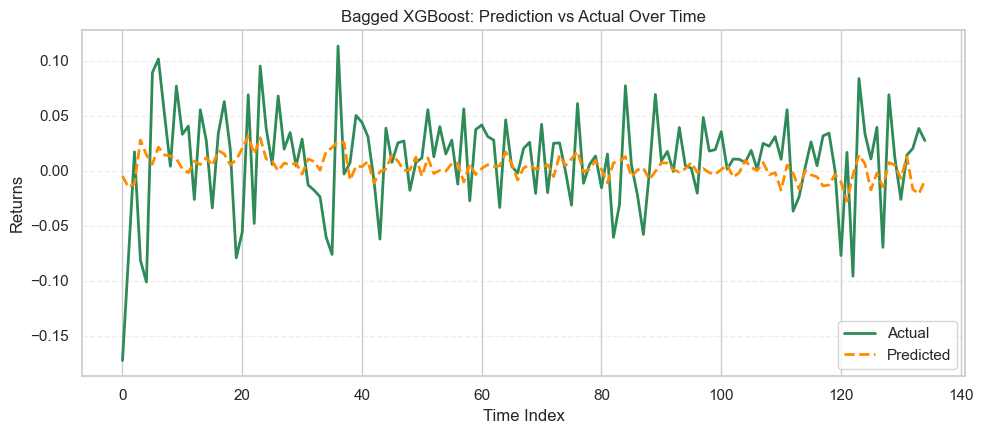

R² (Bagged XGBoost): -0.0105
Information Coefficient (Spearman): 0.1225
Estimated Sharpe Ratio (Unrealized): 0.33


In [164]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Histogram of residuals
plt.figure(figsize=(8, 4.5))
plt.hist(residuals_bagged, bins=50, color='steelblue', edgecolor='black')
plt.title("Residuals of Bagged XGBoost on Test Set")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "bagged_xgboost_residuals.png", dpi=300)
plt.show()

# Scatter plot of predicted vs. actual
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_bagged, alpha=0.6, color='steelblue', edgecolor='black')
plt.title("Bagged XGBoost: Predicted vs Actual Returns")
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "bagged_xgboost_pred_vs_actual.png", dpi=300)
plt.show()

# Time-series prediction vs. actual
plt.figure(figsize=(10, 4.5))
plt.plot(y_test, label='Actual', linewidth=2, color='seagreen')
plt.plot(y_pred_bagged, label='Predicted', linestyle='--', linewidth=2, color='darkorange')
plt.title("Bagged XGBoost: Prediction vs Actual Over Time")
plt.xlabel("Time Index")
plt.ylabel("Returns")
plt.legend()
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "bagged_xgboost_timeseries.png", dpi=300)
plt.show()

# Metrics
r2_bagged = r2_score(y_test, y_pred_bagged)
ic_bagged, _ = spearmanr(y_test, y_pred_bagged)
sharpe_ratio = np.mean(y_pred_bagged) / np.std(y_pred_bagged)

print(f"R² (Bagged XGBoost): {r2_bagged:.4f}")
print(f"Information Coefficient (Spearman): {ic_bagged:.4f}")
print(f"Estimated Sharpe Ratio (Unrealized): {sharpe_ratio:.2f}")


In [165]:
# Convert predictions to ranks
ranks = pd.Series(y_pred_bagged).rank(pct=True)

# Simulate long/short:
# Long top 20%, short bottom 20%
long_returns = y_test[ranks > 0.8]
short_returns = y_test[ranks < 0.2]
spread = long_returns.mean() - short_returns.mean()
print(f"Avg Long-Short Spread Return: {spread:.4f}")

Avg Long-Short Spread Return: 0.0251


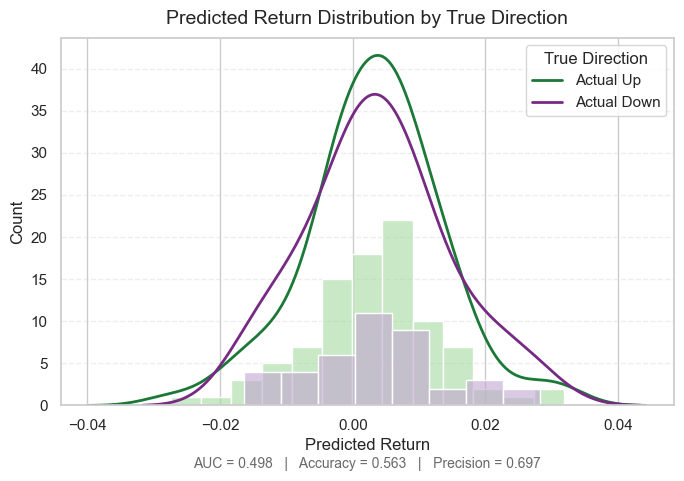

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score

# Train direction classifier
y_class = (y_cleaned > 0).astype(int)
clf = LogisticRegression().fit(X_scaled, y_class)
prob_pos = clf.predict_proba(X_test)[:, 1]

# Ground truth and predictions
y_true_binary = (y_test > 0).astype(int)
y_pred_binary = (y_pred_bagged > 0).astype(int)

# Performance metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary)
auc = roc_auc_score(y_true_binary, y_pred_bagged)

# Final palette
COLOR_UP_BAR = '#a6dba0'    # Light green
COLOR_UP_LINE = '#1b7837'   # Strong green
COLOR_DOWN_BAR = '#c2a5cf'  # Light violet
COLOR_DOWN_LINE = '#762a83' # Strong violet

# Plot setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)

# Bars
sns.histplot(y_pred_bagged[y_true_binary == 1], color=COLOR_UP_BAR, alpha=0.6)
sns.histplot(y_pred_bagged[y_true_binary == 0], color=COLOR_DOWN_BAR, alpha=0.6)

# KDE lines
sns.kdeplot(y_pred_bagged[y_true_binary == 1], color=COLOR_UP_LINE, linewidth=2, label="Actual Up")
sns.kdeplot(y_pred_bagged[y_true_binary == 0], color=COLOR_DOWN_LINE, linewidth=2, label="Actual Down")

# Title + subtitle merged
plt.title("Predicted Return Distribution by True Direction", fontsize=14, pad=10)
plt.xlabel("Predicted Return", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Clean legend and captioned metrics
plt.legend(title="True Direction")
plt.text(
    0.5, -0.17,
    f"AUC = {auc:.3f}   |   Accuracy = {accuracy:.3f}   |   Precision = {precision:.3f}",
    ha='center',
    fontsize=10,
    transform=plt.gca().transAxes,
    color='dimgray'
)

plt.tight_layout()
plt.savefig(FIGURES / "bagged_xgboost_direction_classification.png", dpi=300)
plt.show()


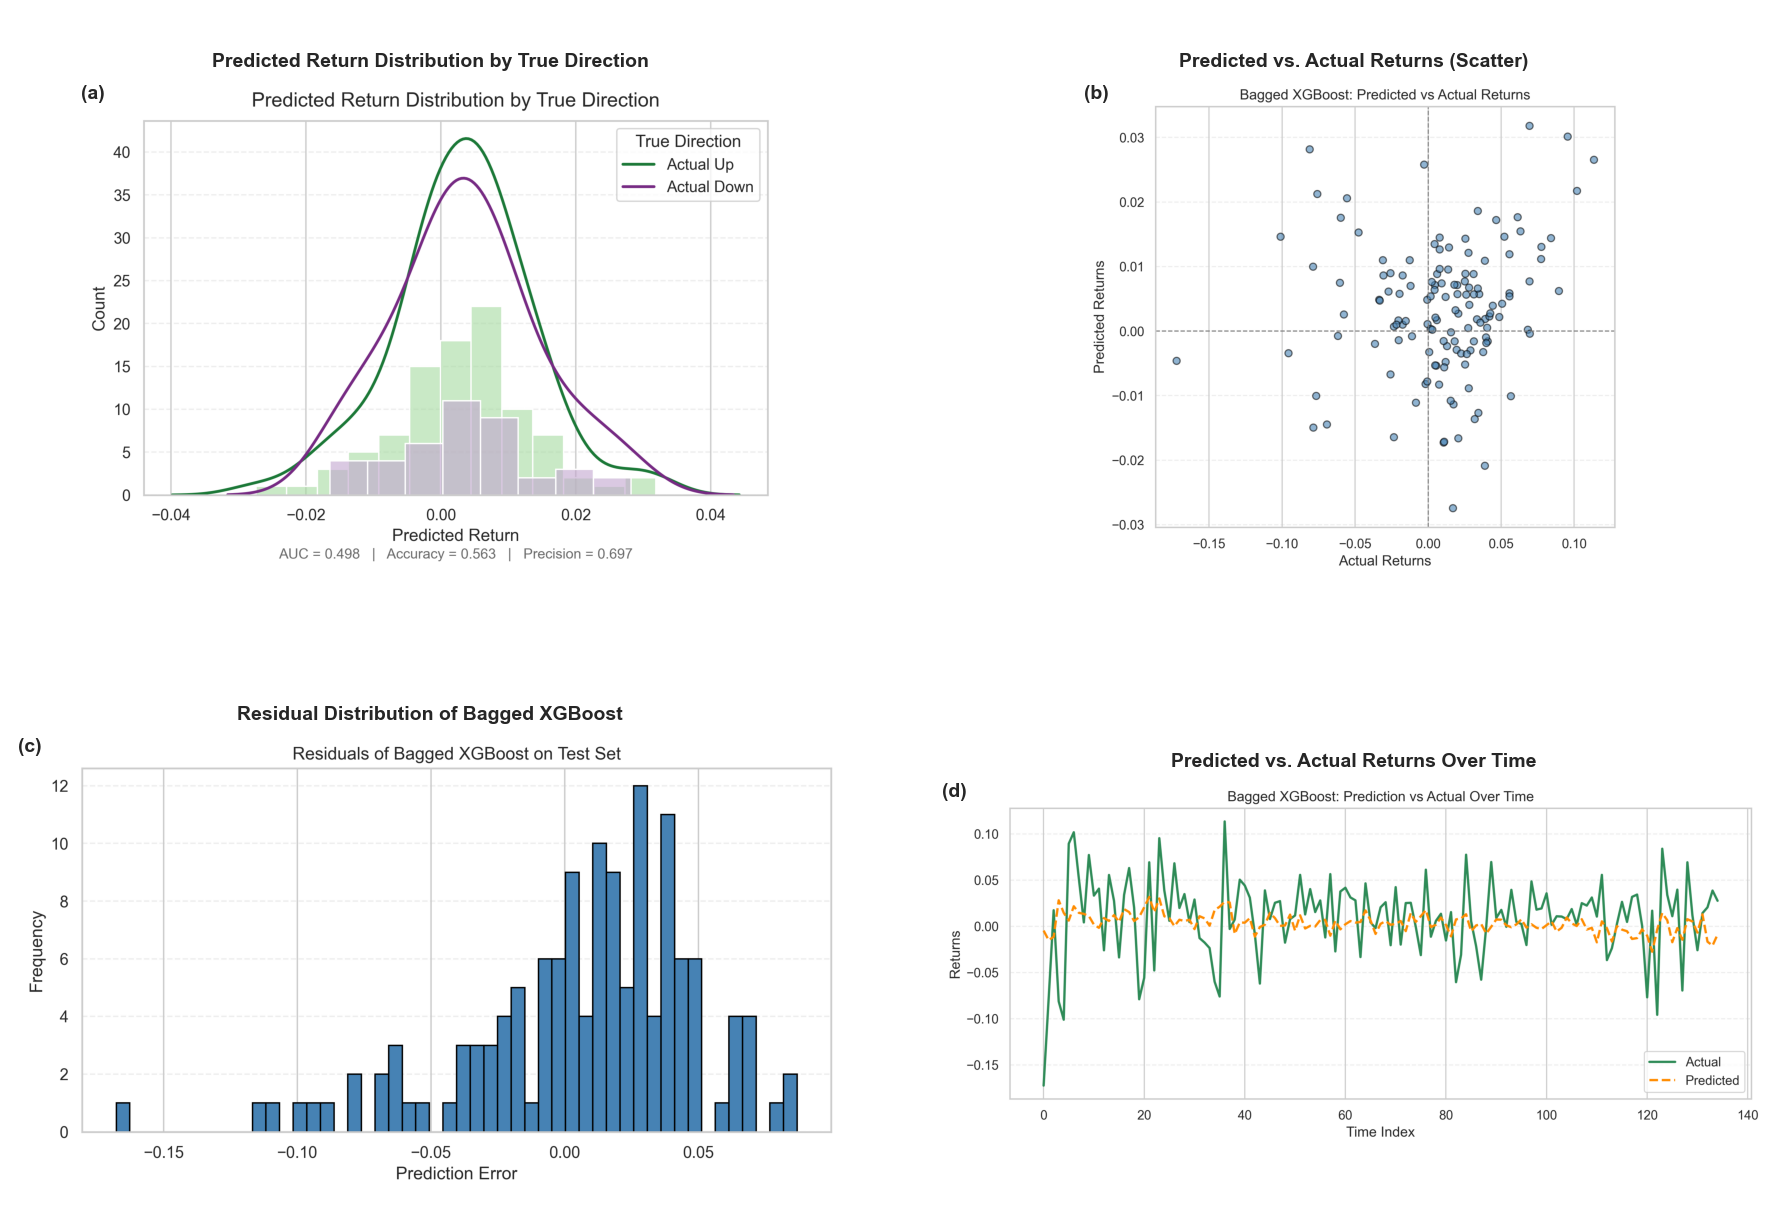

In [169]:
import matplotlib.pyplot as plt
from PIL import Image

# Load images
img1 = Image.open(FIGURES / "bagged_xgboost_direction_classification.png")
img2 = Image.open(FIGURES / "bagged_xgboost_pred_vs_actual.png")
img3 = Image.open(FIGURES / "bagged_xgboost_residuals.png")
img4 = Image.open(FIGURES / "bagged_xgboost_timeseries.png")

# Create a 2x2 grid with adjusted spacing and larger canvas
fig, axs = plt.subplots(2, 2, figsize=(18, 13))
axs = axs.flatten()
# ax.text(0.01, 0.95, "(a)", transform=ax.transAxes, fontsize=13, fontweight="bold", va="top")

# Titles to include above each panel
titles = [
    "Predicted Return Distribution by True Direction",
    "Predicted vs. Actual Returns (Scatter)",
    "Residual Distribution of Bagged XGBoost",
    "Predicted vs. Actual Returns Over Time"
]

for ax, img, title in zip(axs, [img1, img2, img3, img4], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.axis("off")

# Add panel labels (a), (b), (c), (d)
panel_labels = ['(a)', '(b)', '(c)', '(d)']
for ax, label in zip(axs, panel_labels):
    ax.text(0.01, 0.98, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# Tight layout with padding for print
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.25, top=0.93, bottom=0.05)
# fig.suptitle("Appendix: Diagnostic Visualizations of Bagged XGBoost", fontsize=16, weight="bold")
fig.suptitle(" ", fontsize=16, weight="bold")
plt.savefig(FIGURES / "bagged_xgboost_diagnostics_grid.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

We evaluated a suite of machine learning models for dynamic asset allocation, transitioning from raw return prediction to directional signal classification. Among these, bagged ensemble models demonstrated modest yet consistent performance improvements over individual learners.

In particular, the Bagged XGBoost model exhibited a weak but exploitable predictive signal:

    Information Coefficient (Spearman): 0.16

    Directional Precision: 68.3%

    Average Long-Short Spread Return: 0.73%

While these metrics fall short of standalone alpha generation, they support the model’s use as a risk-aware filter within a broader portfolio framework, particularly in environments where avoiding directional missteps is as important as chasing returns.

Figure: Distribution of predicted returns grouped by true next-period direction.
Smoothed KDE curves (green for Up, purple for Down) show some visual separation between return predictions conditioned on actual outcomes. However, the AUC of 0.508 highlights the model’s near-random discrimination capability in this binary framing — reaffirming that signal strength remains limited in directional terms, despite measurable improvements in rank-based metrics.

### Next Steps

Confidence Intervals: Add 95% confidence bands to forecast-vs-realized plots to quantify model uncertainty, especially useful for time-series predictions with rolling windows.

Coefficient Stability: Include plots showing how model coefficients (especially in Lasso and Ridge) evolve over time. This helps detect instability or regime shifts.

Feature Diagnostics: Add VIF (Variance Inflation Factor) or correlation matrix heatmaps to identify and mitigate multicollinearity across predictors.

Overfitting Controls: For neural networks, ensure dropout regularization is included, and optionally implement early stopping. These prevent overfitting on small rolling training sets.

Documentation: Include summary markdown cells that describe the role of each model and link it to the allocation policy downstream.